In [1]:
import ast

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

In [3]:
dataset=load_dataset('lukebarousse/data_jobs')

df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [10]:
df_location = df.groupby(['job_location']).size()

df_location = df_location.reset_index(name='Postings_Count')

df_location

,job_location,Postings_Count
0,"'s-Graveland, Netherlands",1
1,"'s-Gravendeel, Netherlands",2
2,"'s-Heerenberg, Netherlands",1
3,"'s-Hertogenbosch, Netherlands",292
4,"'t Harde, Netherlands",4
...,...,...
17212,"Žebrák, Czechia",1
17213,"Žilina, Slovakia",7
17214,"Șelimbăr, Romania",2
17215,"محافظة جبل لبنان., Lebanon",1


In [11]:
df_location = df_location.sort_values(by='Postings_Count', ascending=False)

df_location

,job_location,Postings_Count
607,Anywhere,69552
14051,Singapore,23415
11529,"Paris, France",12311
1543,"Bengaluru, Karnataka, India",11474
8855,"London, UK",10564
...,...,...
24,"Aalsmeerderbrug, Netherlands",1
26,"Aalst, Belgium (+2 others)",1
30,"Aarhus C, Denmark",1
17185,"Ølstykke, Denmark",1


In [7]:
df_title = df.groupby('job_title_short').size()

df_title= df_title.reset_index(name='Count')

df_title

,job_title_short,Count
0,Business Analyst,49063
1,Cloud Engineer,12331
2,Data Analyst,196075
3,Data Engineer,186241
4,Data Scientist,172286
5,Machine Learning Engineer,14080
6,Senior Data Analyst,29216
7,Senior Data Engineer,44563
8,Senior Data Scientist,36957
9,Software Engineer,44929


In [9]:
df_title = df_title.sort_values(by='Count', ascending=False)

df_title

,job_title_short,Count
2,Data Analyst,196075
3,Data Engineer,186241
4,Data Scientist,172286
0,Business Analyst,49063
9,Software Engineer,44929
7,Senior Data Engineer,44563
8,Senior Data Scientist,36957
6,Senior Data Analyst,29216
5,Machine Learning Engineer,14080
1,Cloud Engineer,12331


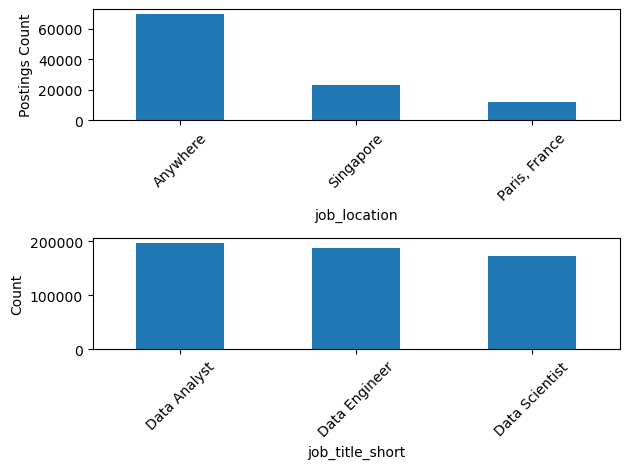

In [17]:
fig , ax = plt.subplots(2,1)

df_location.head(3).plot(kind='bar', x='job_location', y='Postings_Count', ax=ax[0], legend=False)
df_title.head(3).plot(kind='bar', x='job_title_short', y='Count', ax=ax[1], legend=False)
ax[0].set_ylabel('Postings Count')
ax[1].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='x', rotation=45)

fig.tight_layout()